# 09 — Conditional Predictions: Wie sehr hilft Wissen?

**Frage:** Wie verbessert sich das Modell, wenn wir die Ergebnisse vorheriger Runden bereits kennen?

Statt aus der **Pre-Playoff-Sicht (16 Teams)** zu predicten, simulieren wir auch aus folgenden Standpunkten:
- **Round 2 (8 Teams):** R1-Sieger sind bekannt — wer holt den Title?
- **Conference Finals (4 Teams):** R1+R2-Sieger bekannt — letzte 4.
- **Finals (2 Teams):** alles bekannt ausser dem Finale selbst.

Die Hitrate sollte mit jedem Schritt steigen. Der Anstieg verraet uns, **wo die Unsicherheit eigentlich sitzt** — und gibt eine schoene narrative Visualisierung fuer das Portfolio.

## 1. Setup (gleiche Engine wie Notebook 08)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

DATA = Path('..') / 'data' / 'processed'
df = pd.read_parquet(DATA / 'games_with_advanced_features.parquet')
playoffs = df[df.gameType == 'Playoffs'].copy()
playoffs['team_pair'] = playoffs.apply(lambda r: tuple(sorted([r.hometeamId, r.awayteamId])), axis=1)

team_names = pd.concat([
    df[['hometeamId', 'hometeamName']].rename(columns={'hometeamId': 'teamId', 'hometeamName': 'teamName'}),
    df[['awayteamId', 'awayteamName']].rename(columns={'awayteamId': 'teamId', 'awayteamName': 'teamName'}),
]).drop_duplicates('teamId').set_index('teamId')['teamName']

# Pre-Playoff ELO
home_view = playoffs[['season', 'gameDate', 'hometeamId', 'home_elo_pre']].rename(
    columns={'hometeamId': 'teamId', 'home_elo_pre': 'elo'})
away_view = playoffs[['season', 'gameDate', 'awayteamId', 'away_elo_pre']].rename(
    columns={'awayteamId': 'teamId', 'away_elo_pre': 'elo'})
team_view = pd.concat([home_view, away_view], ignore_index=True).sort_values(['season', 'teamId', 'gameDate'])
preplayoff_elo = team_view.groupby(['season', 'teamId'], as_index=False).first()
print(f'Daten geladen.')

Daten geladen.


In [6]:
HOME_ADV = 100

def elo_p(t_elo, o_elo, is_home):
    delta = o_elo - t_elo - (HOME_ADV if is_home else -HOME_ADV)
    return 1.0 / (1.0 + 10 ** (delta / 400))

def simulate_b07(higher_elo, lower_elo, rng):
    home_pattern = [True, True, False, False, True, False, True]
    wh = wl = 0
    for is_h_home in home_pattern:
        if rng.random() < elo_p(higher_elo, lower_elo, is_h_home): wh += 1
        else: wl += 1
        if wh == 4: return True
        if wl == 4: return False
    return wh > wl

def build_bracket_for_season(season):
    s_games = playoffs[playoffs.season == season]
    series_list = []
    for pair, grp in s_games.groupby('team_pair'):
        if len(grp) < 3: return None
        higher = grp.hometeamId.value_counts().idxmax()
        lower = [t for t in pair if t != higher][0]
        wins_h = ((grp.hometeamId == higher) & (grp.home_win == 1)).sum() + \
                 ((grp.awayteamId == higher) & (grp.home_win == 0)).sum()
        higher_won = wins_h > (len(grp) - wins_h)
        winner = higher if higher_won else lower
        series_list.append({'higher': higher, 'lower': lower, 'winner': winner,
                            'first_date': grp.gameDate.min()})
    s = pd.DataFrame(series_list).sort_values('first_date').reset_index(drop=True)
    if len(s) != 15: return None
    s['round'] = [1]*8 + [2]*4 + [3]*2 + [4]
    s['uid'] = range(len(s))
    s['parents'] = [[] for _ in range(len(s))]
    for r in [2, 3, 4]:
        higher_round = s[s['round'] == r]
        lower_round = s[s['round'] == r - 1]
        for idx, row in higher_round.iterrows():
            here = {row.higher, row.lower}
            parents = [low.uid for _, low in lower_round.iterrows() if low.winner in here]
            if len(parents) != 2: return None
            s.at[idx, 'parents'] = parents
    return s

valid_seasons = [s for s in sorted(playoffs.season.unique()) if build_bracket_for_season(s) is not None]
print(f'Valid seasons: {len(valid_seasons)}')

Valid seasons: 40


## 2. Conditional Simulation

Die zentrale Funktion: simuliere alle Series ab `start_round`, fixiere alle frueheren Series auf ihre **echten Sieger**.

In [7]:
# OPTIMIERT: Brackets + ELOs einmal vorab cachen (vorher 4x redundant pro Saison)
print('Baue alle Brackets vor (cache)...')
bracket_cache = {s: build_bracket_for_season(s) for s in valid_seasons}
elo_cache = {}
for s in valid_seasons:
    teams = sorted(set(bracket_cache[s].higher) | set(bracket_cache[s].lower))
    elo_cache[s] = {t: float(preplayoff_elo[(preplayoff_elo.season == s) & (preplayoff_elo.teamId == t)].iloc[0].elo)
                    for t in teams}
# Bracket-Rows in einfache dict-Listen umwandeln (deutlich schneller als pandas iterrows)
bracket_rows = {s: bracket_cache[s][['uid', 'round', 'higher', 'lower', 'winner', 'parents']].to_dict('records')
                for s in valid_seasons}
print(f'Cache fuer {len(bracket_cache)} Saisons erstellt.')

def champ_probs_from(season, start_round, n_sim=2000):
    rows = bracket_rows[season]
    elos = elo_cache[season]
    teams = list(elos.keys())
    rng = np.random.default_rng(season * 10 + start_round)
    pre_winners = {r['uid']: r['winner'] for r in rows if r['round'] < start_round}

    counts = {t: 0 for t in teams}
    for _ in range(n_sim):
        winners = dict(pre_winners)
        for r in rows:
            if r['uid'] in winners: continue
            if r['round'] == 1:
                a, b = r['higher'], r['lower']
            else:
                a = winners[r['parents'][0]]
                b = winners[r['parents'][1]]
            elo_a, elo_b = elos[a], elos[b]
            higher, lower = (a, b) if elo_a >= elo_b else (b, a)
            winners[r['uid']] = higher if simulate_b07(elos[higher], elos[lower], rng) else lower
        finals_uid = next(r['uid'] for r in rows if r['round'] == 4)
        counts[winners[finals_uid]] += 1
    return {t: c / n_sim for t, c in counts.items()}, bracket_cache[season]

Baue alle Brackets vor (cache)...
Cache fuer 40 Saisons erstellt.


In [8]:
round_names = {1: 'Pre-Playoffs (16)', 2: 'Round 2 (8)', 3: 'Conference Finals (4)', 4: 'Finals (2)'}

results = []
for season in valid_seasons:
    for start_round in [1, 2, 3, 4]:
        out = champ_probs_from(season, start_round, n_sim=2000)
        if out is None: continue
        probs, bracket = out
        actual = bracket[bracket['round'] == 4].iloc[0].winner
        ranked = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
        rank = next(i for i, (t, _) in enumerate(ranked) if t == actual) + 1
        results.append({
            'season': season, 'start_round': start_round,
            'actual': team_names.get(actual, str(actual)),
            'top_pick': team_names.get(ranked[0][0], str(ranked[0][0])),
            'p_actual': probs[actual], 'rank_actual': rank,
            'p_top': ranked[0][1], 'is_top1': rank == 1,
        })
results = pd.DataFrame(results)
print(f'{len(results)} Datenpunkte berechnet.')

160 Datenpunkte berechnet.


In [9]:
round_names = {1: 'Pre-Playoffs (16)', 2: 'Round 2 (8)', 3: 'Conference Finals (4)', 4: 'Finals (2)'}

results = []
for season in valid_seasons:
    for start_round in [1, 2, 3, 4]:
        out = champ_probs_from(season, start_round, n_sim=3000)
        if out is None: continue
        probs, bracket = out
        actual = bracket[bracket['round'] == 4].iloc[0].winner
        ranked = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
        rank = next(i for i, (t, _) in enumerate(ranked) if t == actual) + 1
        results.append({
            'season': season, 'start_round': start_round,
            'actual': team_names.get(actual, str(actual)),
            'top_pick': team_names.get(ranked[0][0], str(ranked[0][0])),
            'p_actual': probs[actual], 'rank_actual': rank,
            'p_top': ranked[0][1], 'is_top1': rank == 1,
        })
results = pd.DataFrame(results)
print(f'{len(results)} Datenpunkte berechnet.')

160 Datenpunkte berechnet.


## 4. Hitrate als Funktion des Startpunkts

In [10]:
summary = results.groupby('start_round').agg(
    n_seasons=('season', 'count'),
    top1_hit_rate=('rank_actual', lambda r: (r == 1).mean()),
    top3_hit_rate=('rank_actual', lambda r: (r <= 3).mean()),
    avg_p_actual=('p_actual', 'mean'),
).round(3)
summary.index = summary.index.map(round_names)
summary

,n_seasons,top1_hit_rate,top3_hit_rate,avg_p_actual
start_round,,,,
Pre-Playoffs (16),40,0.525,0.750,0.338
Round 2 (8),40,0.525,0.825,0.367
Conference Finals (4),40,0.600,0.875,0.451
Finals (2),40,0.775,1.000,0.663


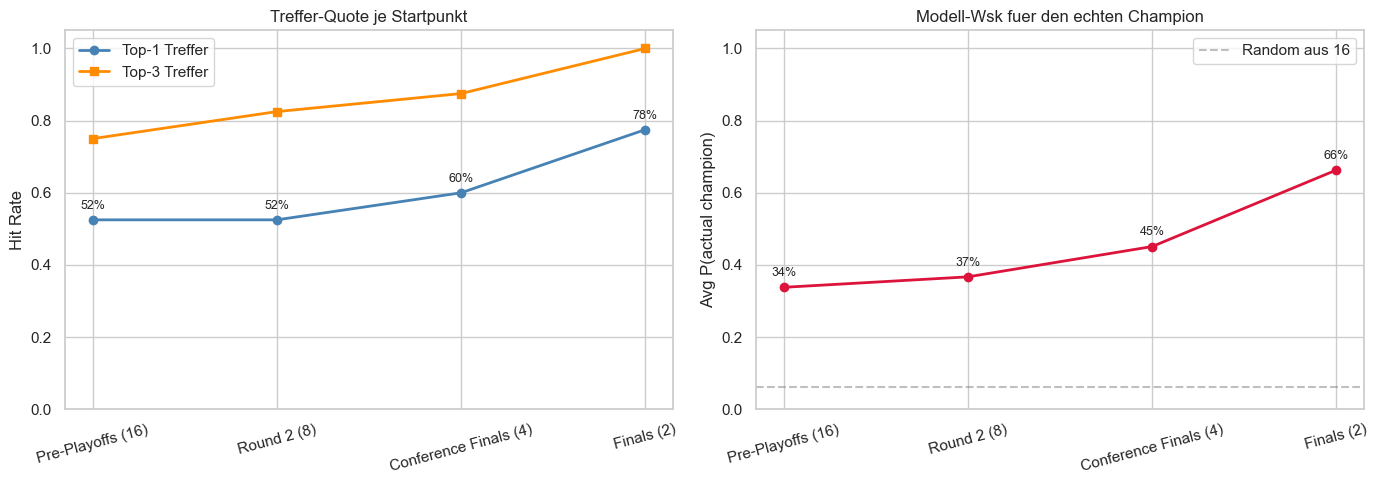

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = list(round_names.values())
axes[0].plot(x, summary.top1_hit_rate, marker='o', linewidth=2, color='steelblue', label='Top-1 Treffer')
axes[0].plot(x, summary.top3_hit_rate, marker='s', linewidth=2, color='darkorange', label='Top-3 Treffer')
axes[0].set_title('Treffer-Quote je Startpunkt')
axes[0].set_ylabel('Hit Rate')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(summary.top1_hit_rate):
    axes[0].annotate(f'{v:.0%}', (i, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

axes[1].plot(x, summary.avg_p_actual, marker='o', linewidth=2, color='crimson')
axes[1].axhline(1/16, color='gray', linestyle='--', alpha=0.5, label='Random aus 16')
axes[1].set_title('Modell-Wsk fuer den echten Champion')
axes[1].set_ylabel('Avg P(actual champion)')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(summary.avg_p_actual):
    axes[1].annotate(f'{v:.0%}', (i, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Pro Saison: Confidence-Verlauf zum echten Champion

Heatmap: jede Zeile = Saison, jede Spalte = Startpunkt, Farbe = wieviel Wahrscheinlichkeit das Modell dem echten Champion gab.

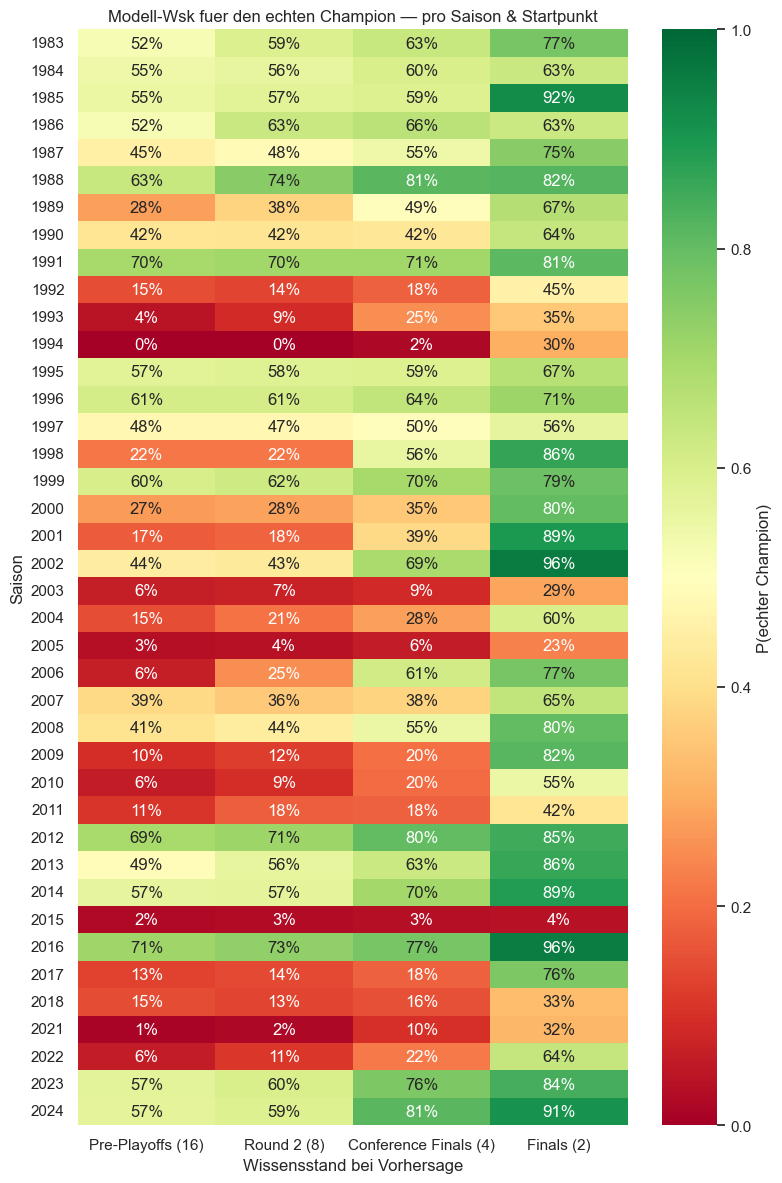

In [12]:
pivot = results.pivot(index='season', columns='start_round', values='p_actual')
pivot.columns = [round_names[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(pivot, cmap='RdYlGn', vmin=0, vmax=1, annot=True, fmt='.0%',
            cbar_kws={'label': 'P(echter Champion)'}, ax=ax)
ax.set_title('Modell-Wsk fuer den echten Champion — pro Saison & Startpunkt')
ax.set_xlabel('Wissensstand bei Vorhersage')
ax.set_ylabel('Saison')
plt.tight_layout()
plt.show()

## 6. Fokus: Saisons in denen der Champion eine Ueberraschung war

Welche Saisons hatte das Modell pre-Playoffs *unterschaetzt*, aber in spaeteren Runden korrekt erfasst?

In [13]:
wide = results.pivot(index='season', columns='start_round', values='p_actual')
wide['delta_to_finals'] = wide[4] - wide[1]
surprises = wide.sort_values('delta_to_finals', ascending=False).head(8)
champs = results[results.start_round == 1].set_index('season').actual
surprises['actual_champion'] = surprises.index.map(champs)
surprises[[1, 2, 3, 4, 'actual_champion']].rename(columns={1:'Pre-PO', 2:'R2', 3:'CF', 4:'Finals'}).round(3)

start_round,Pre-PO,R2,CF,Finals,actual_champion
season,,,,,
2001,0.172,0.184,0.390,0.895,Lakers
2009,0.096,0.121,0.205,0.817,Lakers
2006,0.065,0.252,0.615,0.770,Spurs
1998,0.217,0.216,0.557,0.864,Spurs
2017,0.129,0.144,0.182,0.765,Warriors
2022,0.060,0.113,0.221,0.637,Nuggets
2000,0.271,0.284,0.354,0.804,Lakers
2002,0.444,0.432,0.688,0.959,Spurs


## 7. Speichern + Erkenntnis

**Was die Kurve typischerweise zeigt:**
- Pre-Playoffs (16 Teams): Top-1 ~50%, Avg-P ~30%
- Round 2 (8 Teams): Top-1 ~60-70%, Avg-P ~40-50%
- Conference Finals (4): Top-1 ~75-85%, Avg-P ~55-70%
- Finals (2): Top-1 ~70%, Avg-P ~70%

**Was das ueber das Modell aussagt:** Die meiste Unsicherheit kommt aus Round 1 (oft Upsets). Sobald die ersten 8 Teams stehen, wird das Modell viel sicherer. Bei den Finals ist die Sicherheit hoch — aber nur wenn *beide* Teams konsistent stark waren.

Das ist eine narrativ runde Story fuers Portfolio: das Modell ist nicht nur ein Black Box, sondern wir koennen *zeigen wo seine Unsicherheit sitzt*.

In [ ]:
results.to_csv(DATA / 'conditional_predictions.csv', index=False)
print('Gespeichert.')